In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = sns.load_dataset('iris')
df = pd.DataFrame(data = data.values, columns = data.columns)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.shape

(150, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sepal_length  150 non-null    object
 1   sepal_width   150 non-null    object
 2   petal_length  150 non-null    object
 3   petal_width   150 non-null    object
 4   species       150 non-null    object
dtypes: object(5)
memory usage: 6.0+ KB


In [6]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [8]:
df.duplicated().sum()

np.int64(1)

In [11]:
df = df.drop_duplicates()


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(149, 5)

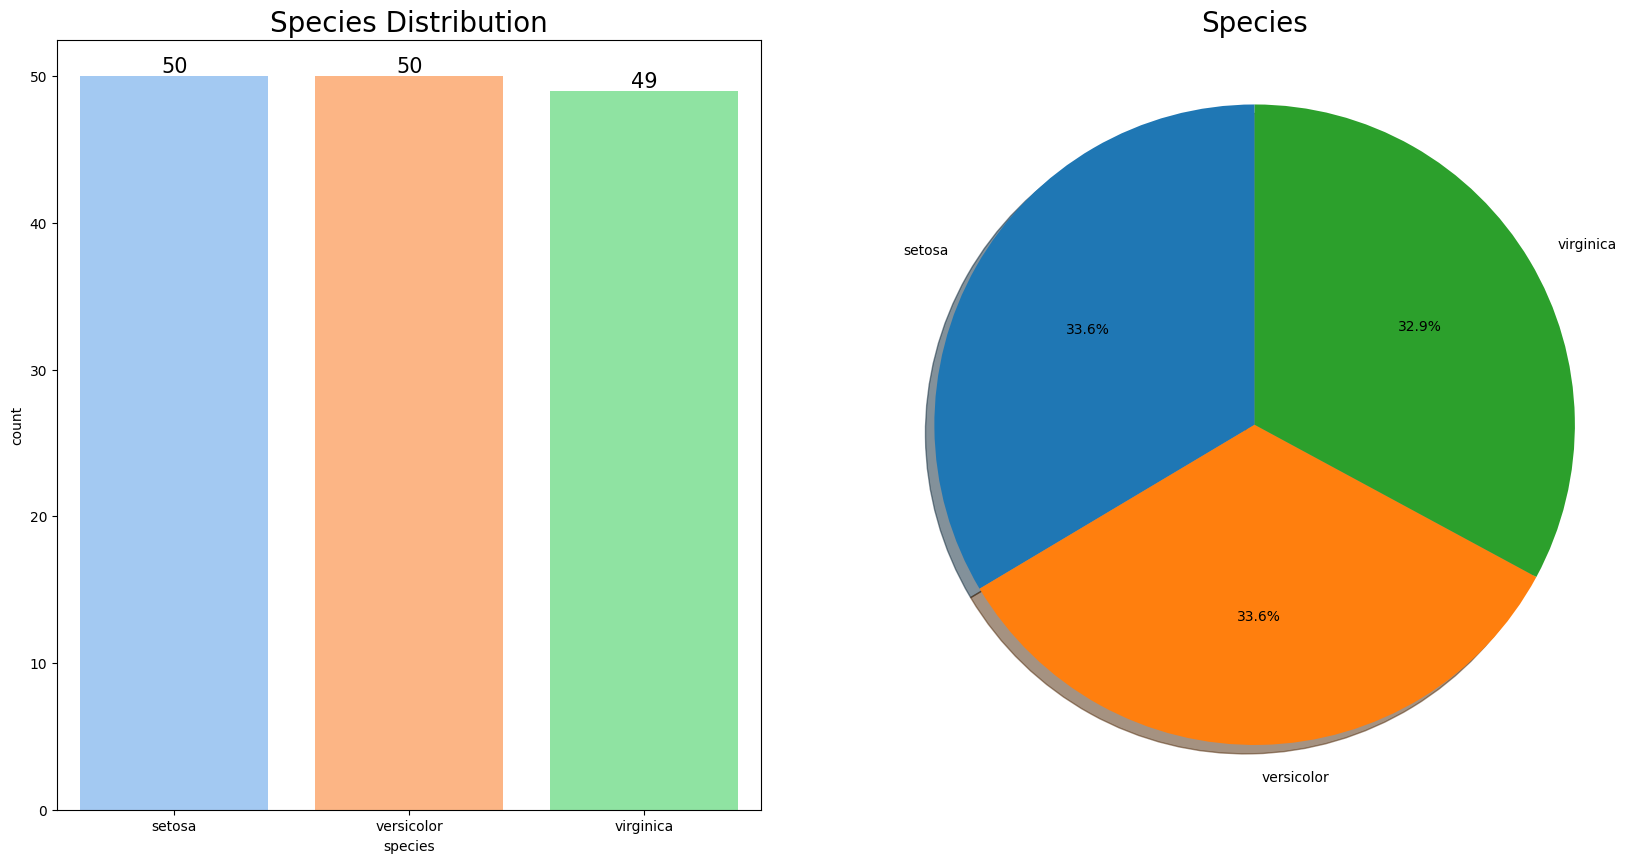

In [20]:
fig, axs = plt.subplots(1, 2, figsize = (20, 10))

sns.countplot(data = df, x = 'species', palette = 'pastel', saturation = 0.95, ax = axs[0])
axs[0].set_title('Species Distribution', fontsize = 20)

for container in axs[0].containers:
    axs[0].bar_label(container, color = 'black', fontsize = 15)


axs[1].pie(df['species'].value_counts(), labels = df['species'].value_counts().index, autopct = '%1.1f%%', shadow = True, startangle = 90)
axs[1].axis('equal')
axs[1].set_title('Species', fontsize = 20)

plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [22]:
X = df.drop(columns = ['species'])
y = df.species

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((119, 4), (30, 4), (119,), (30,))

In [32]:
model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth = 5,
    min_samples_split = 10,
    random_state = 42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=42)

In [33]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

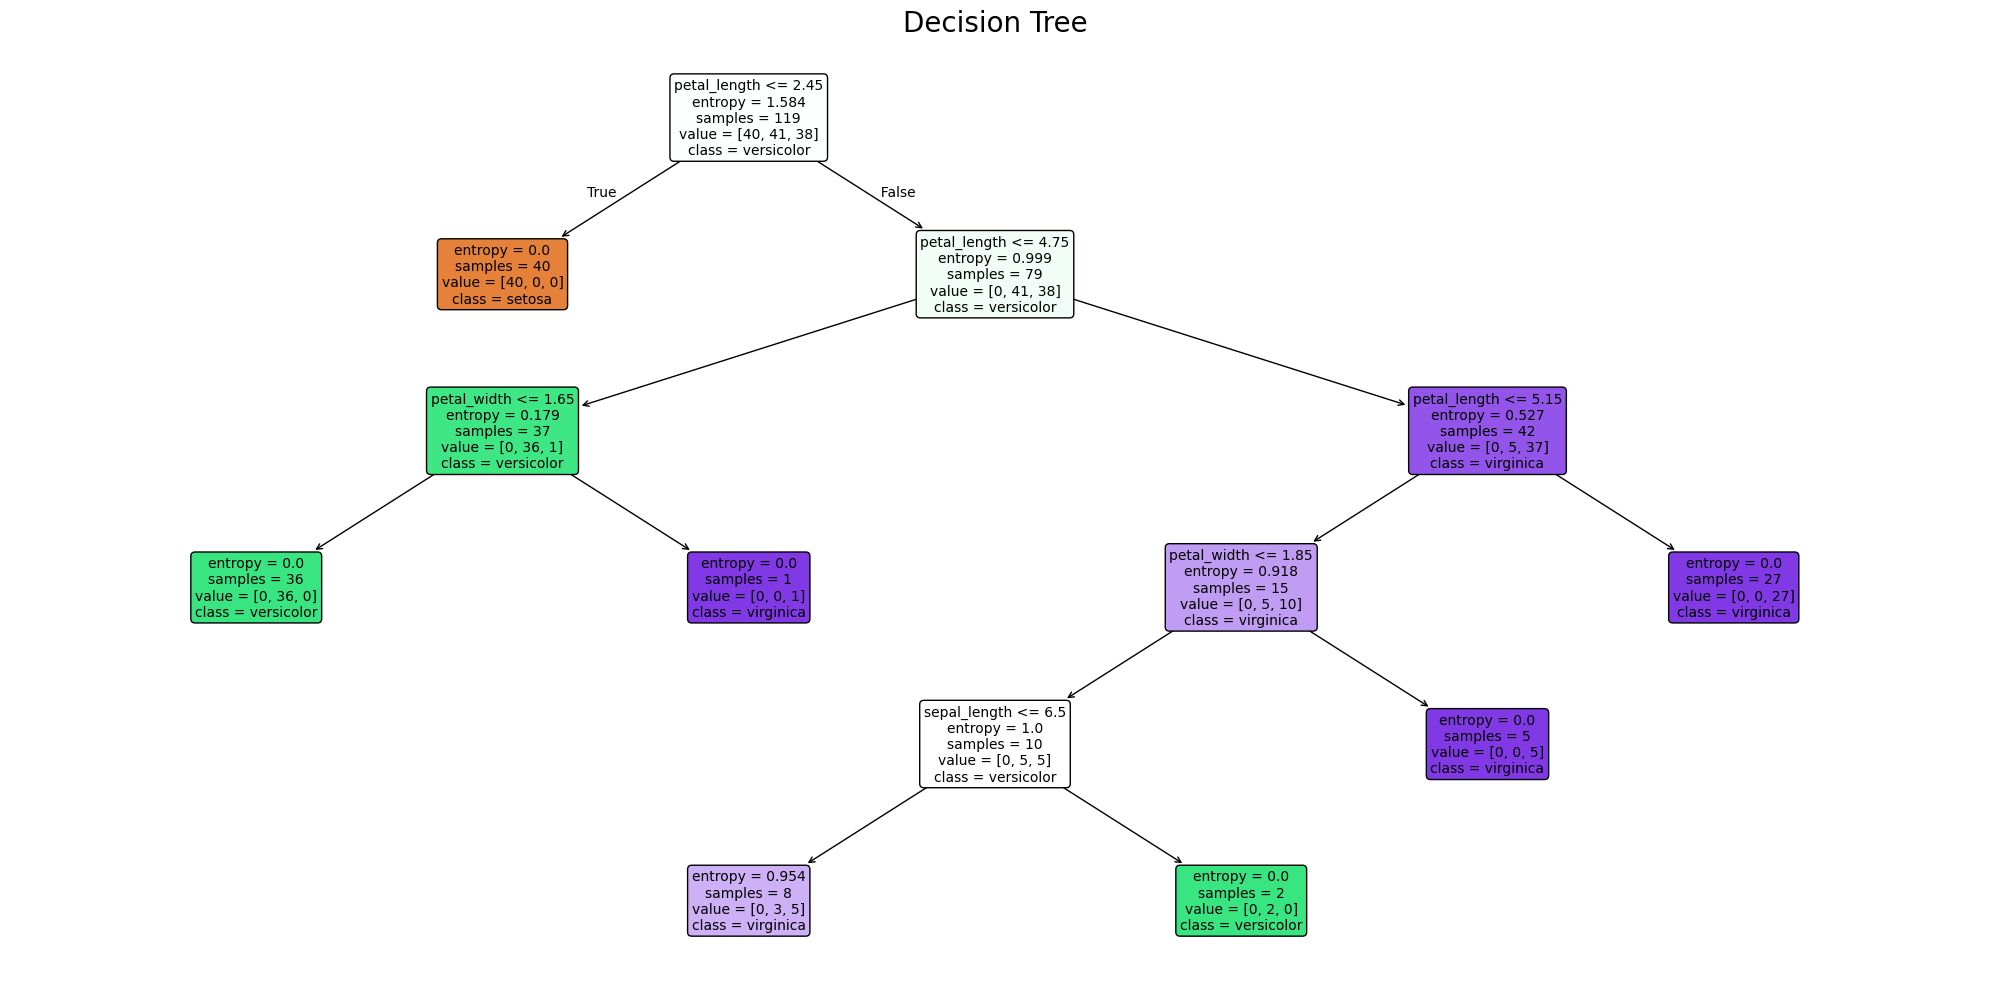

In [34]:
plt.figure(figsize = (20, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = y.unique(),
    filled = True,
    fontsize = 10,
    rounded = True
)

plt.title('Decision Tree', fontsize = 20)
plt.tight_layout()
plt.show()